<a href="https://colab.research.google.com/github/Nasreen245345/ML_Pipeline_CustomerChurn/blob/main/Task2_ML_Pipeline_CustomerChurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Task 2: End-to-End ML Pipeline with Scikit-learn
## Customer Churn Prediction — DevelopersHub Corporation Internship

---

###  Problem Statement
Customer churn (when customers stop using a service) is a critical business problem for telecom companies. Predicting churn early allows companies to take proactive retention actions.

###  Objective
Build a **production-ready, reusable ML pipeline** that:
- Preprocesses raw customer data (scaling, encoding)
- Trains and compares Logistic Regression & Random Forest models
- Tunes hyperparameters using GridSearchCV
- Exports the best pipeline using joblib for deployment

###  Tools Used
`scikit-learn` | `pandas` | `numpy` | `matplotlib` | `seaborn` | `joblib`

---
## Step 1: Install & Import Libraries

In [ ]:
# Install any missing packages (Colab usually has these)
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

In [ ]:
# ── Core Libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn Pipeline & Preprocessing ──
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# ── Models ──
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ── Model Selection & Evaluation ──
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

print('✅ All libraries imported successfully!')
print(f'Scikit-learn version: {__import__("sklearn").__version__}')

✅ All libraries imported successfully!
Scikit-learn version: 1.7.2


---
## Step 2: Load the Telco Churn Dataset

In [ ]:
# Load directly from GitHub (Telco Customer Churn dataset)
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Basic info
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Target Distribution ===')
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']:.2%}")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

---
## Step 3: Exploratory Data Analysis (EDA)

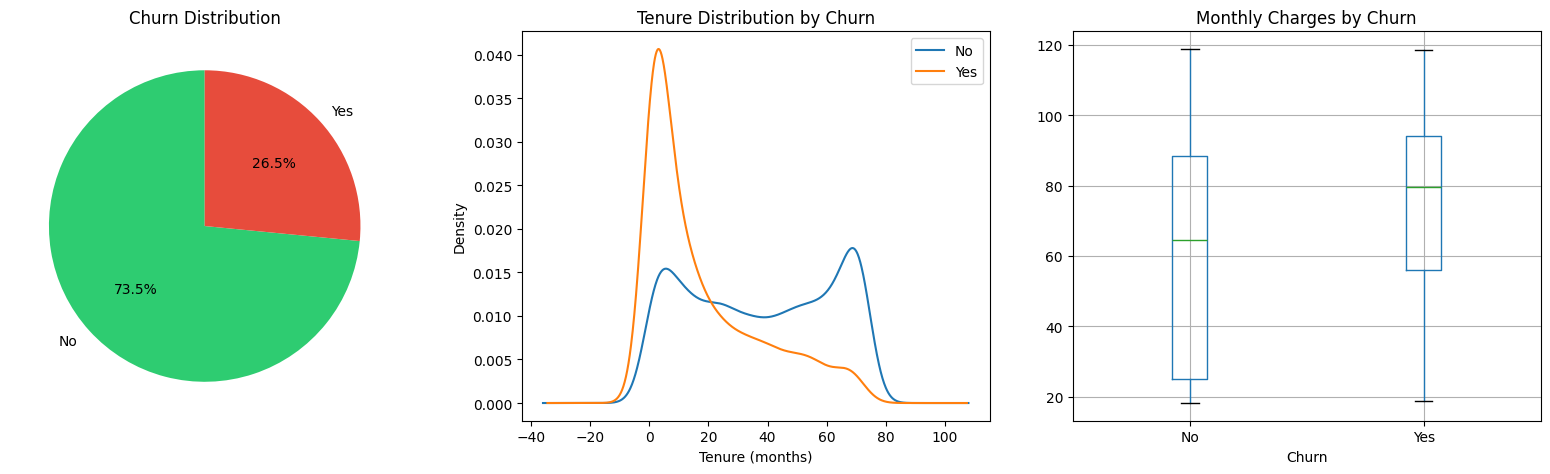

✅ EDA plots saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA: Customer Churn Overview', fontsize=16, fontweight='bold')

# 1. Churn Distribution
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Churn Distribution')

# 2. Tenure vs Churn
df.groupby('Churn')['tenure'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Tenure Distribution by Churn')
axes[1].set_xlabel('Tenure (months)')

# 3. Monthly Charges vs Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[2])
axes[2].set_title('Monthly Charges by Churn')
axes[2].set_xlabel('Churn')
plt.suptitle('')  # remove auto title from boxplot

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved!')

<Figure size 1000x500 with 0 Axes>

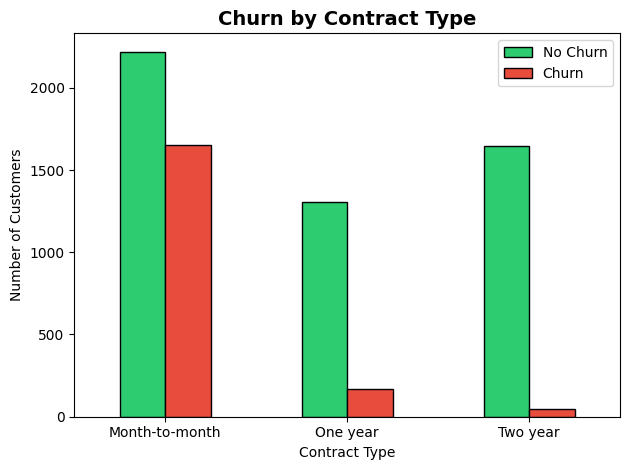

In [ ]:
# Churn by contract type — business insight
plt.figure(figsize=(10, 5))
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 4: Data Preprocessing

In [ ]:
# ── 4.1 Clean raw data ──

# Drop customerID (not a feature)
df.drop('customerID', axis=1, inplace=True)

# TotalCharges has hidden spaces — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Encode target variable: Yes=1, No=0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(f'Missing values after cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nTarget encoding: {df["Churn"].unique()}')

Missing values after cleaning:
TotalCharges    11
dtype: int64

Target encoding: [0 1]


In [ ]:
# ── 4.2 Split features and target ──
X = df.drop('Churn', axis=1)
y = df['Churn']

# ── 4.3 Identify column types ──
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical columns ({len(numerical_cols)}): {numerical_cols}')
print(f'\nCategorical columns ({len(categorical_cols)}): {categorical_cols}')

Numerical columns (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
# ── 4.4 Train-Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size:  {X_train.shape[0]} samples')
print(f'Test set size:      {X_test.shape[0]} samples')
print(f'Churn rate (train): {y_train.mean():.2%}')
print(f'Churn rate (test):  {y_test.mean():.2%}')

Training set size:  5634 samples
Test set size:      1409 samples
Churn rate (train): 26.54%
Churn rate (test):  26.54%


---
## Step 5: Build the Scikit-learn Pipeline

This is the **core production-ready component** — a single pipeline object that handles all preprocessing + model training automatically.

In [ ]:
# ── 5.1 Define sub-pipelines for each column type ──

# Numerical: fill missing values → scale
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # handles NaN in TotalCharges
    ('scaler', StandardScaler())                      # normalize scale
])

# Categorical: fill missing → one-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── 5.2 Combine with ColumnTransformer ──
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print('✅ Preprocessor defined!')
print('   - Numerical: Imputation (median) → StandardScaler')
print('   - Categorical: Imputation (mode) → OneHotEncoder')

✅ Preprocessor defined!
   - Numerical: Imputation (median) → StandardScaler
   - Categorical: Imputation (mode) → OneHotEncoder


In [ ]:
# ── 5.3 Full Pipelines: Preprocessor + Model ──

# Pipeline 1: Logistic Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Pipeline 2: Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

print('✅ Two full pipelines created:')
print('   1. Preprocessor → Logistic Regression')
print('   2. Preprocessor → Random Forest')

✅ Two full pipelines created:
   1. Preprocessor → Logistic Regression
   2. Preprocessor → Random Forest


---
## Step 6: Train & Evaluate Both Models (Baseline)

In [ ]:
def evaluate_model(pipeline, X_train, X_test, y_train, y_test, name):
    """Train a pipeline and print full evaluation metrics."""
    # Train
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cv   = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1').mean()

    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(f'  Accuracy:         {acc:.4f}')
    print(f'  F1-Score:         {f1:.4f}')
    print(f'  ROC-AUC:          {auc:.4f}')
    print(f'  CV F1 (5-fold):   {cv:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

    return {'name': name, 'accuracy': acc, 'f1': f1, 'auc': auc, 'cv_f1': cv,
            'y_pred': y_pred, 'y_prob': y_prob}

# Evaluate both
lr_results = evaluate_model(lr_pipeline, X_train, X_test, y_train, y_test, 'Logistic Regression')
rf_results = evaluate_model(rf_pipeline, X_train, X_test, y_train, y_test, 'Random Forest')


  Logistic Regression
  Accuracy:         0.8055
  F1-Score:         0.6040
  ROC-AUC:          0.8419
  CV F1 (5-fold):   0.5980

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


  Random Forest
  Accuracy:         0.7779
  F1-Score:         0.5321
  ROC-AUC:          0.8162
  CV F1 (5-fold):   0.5431

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1035
       Churn       0.60      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



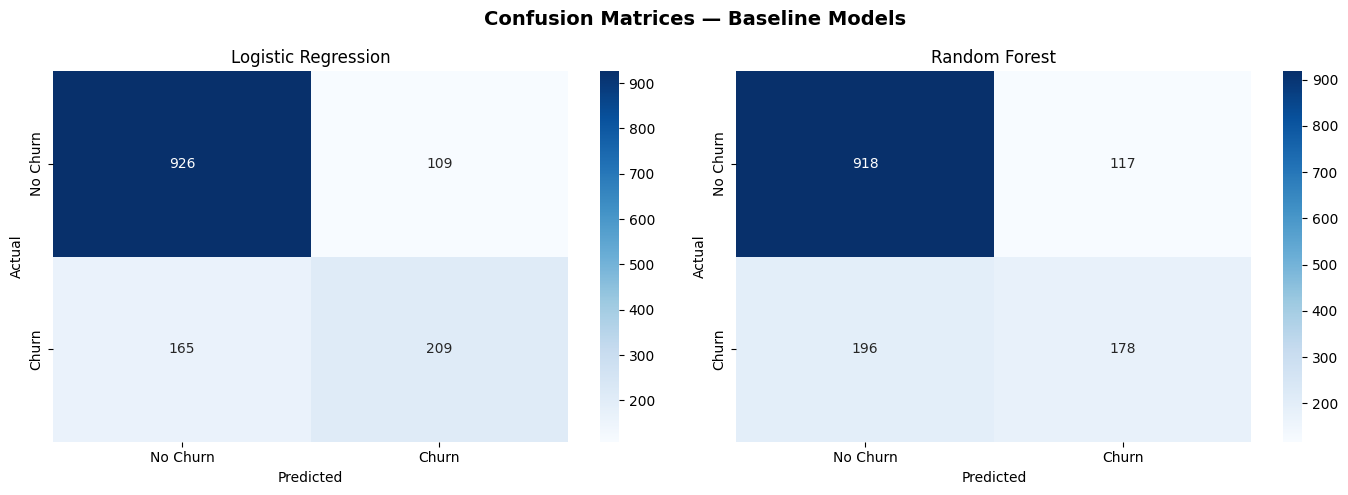

In [ ]:
# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices — Baseline Models', fontsize=14, fontweight='bold')

for ax, results in zip(axes, [lr_results, rf_results]):
    cm = confusion_matrix(y_test, results['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(results['name'])
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

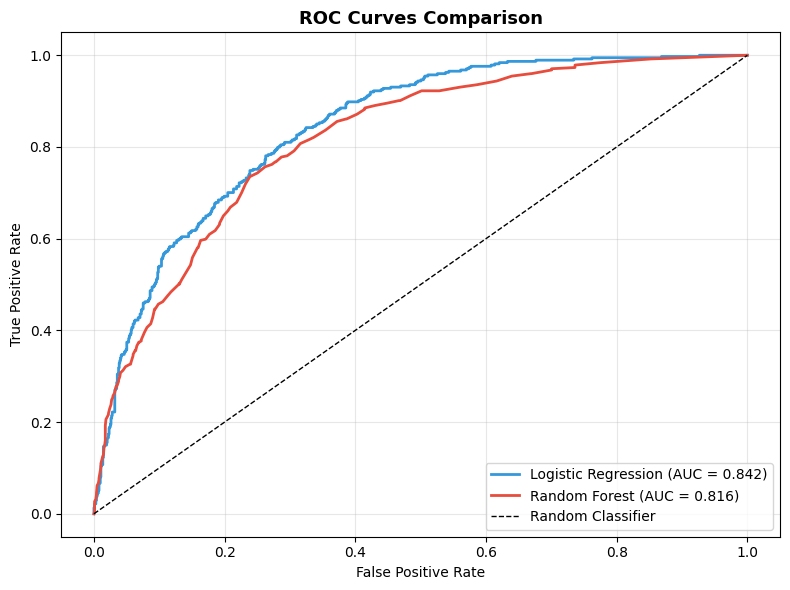

In [ ]:
# ── ROC Curves ──
plt.figure(figsize=(8, 6))

for results, color in zip([lr_results, rf_results], ['#3498db', '#e74c3c']):
    fpr, tpr, _ = roc_curve(y_test, results['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{results['name']} (AUC = {results['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 7: Hyperparameter Tuning with GridSearchCV

In [ ]:
# ── 7.1 Tune Logistic Regression ──
print('🔍 Tuning Logistic Regression...')

lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'liblinear'],
    'classifier__class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(
    lr_pipeline,
    param_grid=lr_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train, y_train)

print(f'\n✅ Best LR Params: {lr_grid.best_params_}')
print(f'   Best CV F1: {lr_grid.best_score_:.4f}')

🔍 Tuning Logistic Regression...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Best LR Params: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__solver': 'lbfgs'}
   Best CV F1: 0.6332


In [ ]:
# ── 7.2 Tune Random Forest ──
print('🔍 Tuning Random Forest...')

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__class_weight': [None, 'balanced']
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print(f'\n✅ Best RF Params: {rf_grid.best_params_}')
print(f'   Best CV F1: {rf_grid.best_score_:.4f}')

🔍 Tuning Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best RF Params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
   Best CV F1: 0.6325


In [ ]:
# ── 7.3 Evaluate tuned models ──
print('\n📊 Evaluating TUNED models on test set...')
lr_tuned_results = evaluate_model(lr_grid.best_estimator_, X_train, X_test, y_train, y_test, 'Logistic Regression (Tuned)')
rf_tuned_results = evaluate_model(rf_grid.best_estimator_, X_train, X_test, y_train, y_test, 'Random Forest (Tuned)')


📊 Evaluating TUNED models on test set...

  Logistic Regression (Tuned)
  Accuracy:         0.7381
  F1-Score:         0.6136
  ROC-AUC:          0.8413
  CV F1 (5-fold):   0.6332

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  Random Forest (Tuned)
  Accuracy:         0.7651
  F1-Score:         0.6110
  ROC-AUC:          0.8380
  CV F1 (5-fold):   0.6325

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.55      0.70      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      

---
## Step 8: Model Comparison & Feature Importance

In [ ]:
# ── 8.1 Summary comparison table ──
results_df = pd.DataFrame([
    {'Model': 'Logistic Regression (Baseline)', 'Accuracy': lr_results['accuracy'],
     'F1-Score': lr_results['f1'], 'ROC-AUC': lr_results['auc']},
    {'Model': 'Random Forest (Baseline)', 'Accuracy': rf_results['accuracy'],
     'F1-Score': rf_results['f1'], 'ROC-AUC': rf_results['auc']},
    {'Model': 'Logistic Regression (Tuned)', 'Accuracy': lr_tuned_results['accuracy'],
     'F1-Score': lr_tuned_results['f1'], 'ROC-AUC': lr_tuned_results['auc']},
    {'Model': 'Random Forest (Tuned)', 'Accuracy': rf_tuned_results['accuracy'],
     'F1-Score': rf_tuned_results['f1'], 'ROC-AUC': rf_tuned_results['auc']},
])

results_df = results_df.set_index('Model')
print('\n=== Final Model Comparison ===')
print(results_df.round(4).to_string())


=== Final Model Comparison ===
                                Accuracy  F1-Score  ROC-AUC
Model                                                      
Logistic Regression (Baseline)    0.8055    0.6040   0.8419
Random Forest (Baseline)          0.7779    0.5321   0.8162
Logistic Regression (Tuned)       0.7381    0.6136   0.8413
Random Forest (Tuned)             0.7651    0.6110   0.8380


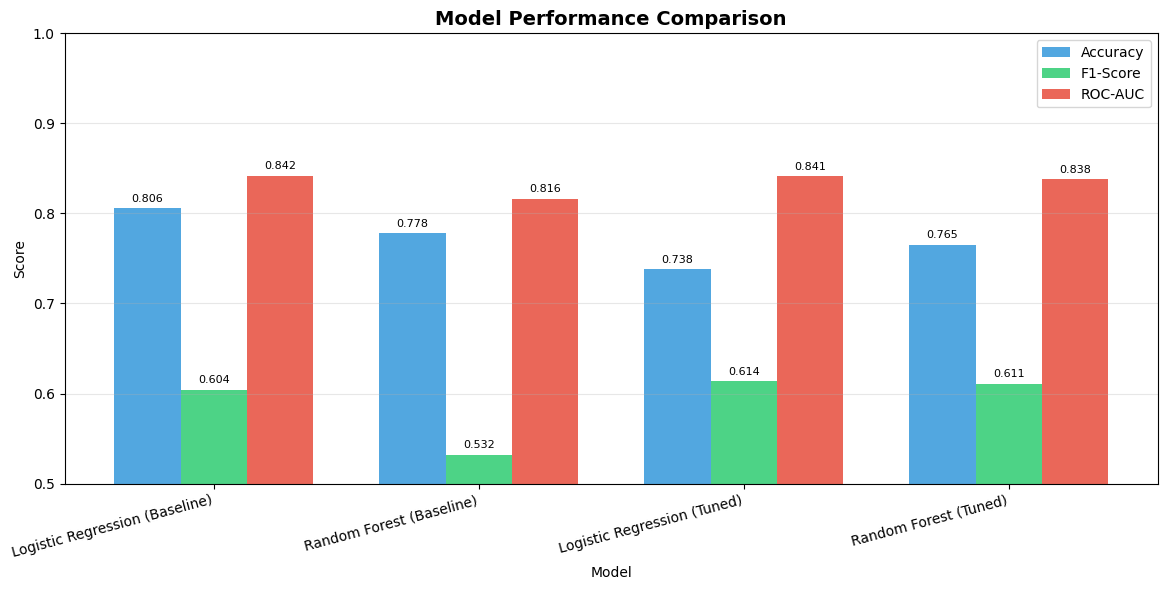

In [ ]:
# ── 8.2 Bar chart comparison ──
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (metric, color) in enumerate(zip(['Accuracy', 'F1-Score', 'ROC-AUC'], colors)):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

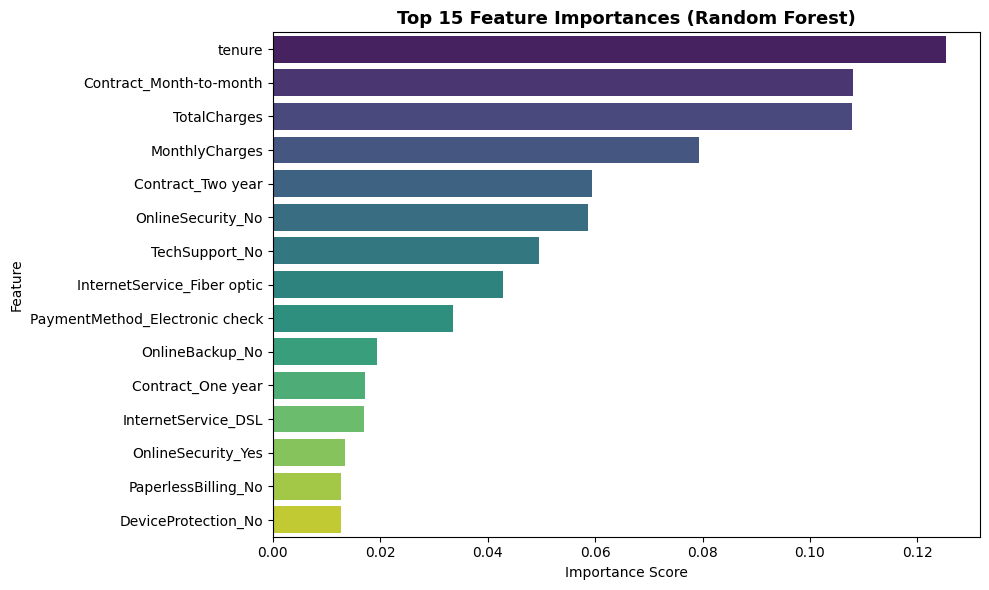

In [ ]:
# ── 8.3 Feature Importance from Best Random Forest ──
best_rf = rf_grid.best_estimator_

# Get feature names after transformation
ohe_features = best_rf.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(categorical_cols)

all_features = numerical_cols + list(ohe_features)
importances = best_rf.named_steps['classifier'].feature_importances_

feat_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9: Select Best Model & Export Pipeline with joblib

In [ ]:
# ── 9.1 Pick best model based on F1 ──
best_f1_lr = lr_tuned_results['f1']
best_f1_rf = rf_tuned_results['f1']

if best_f1_rf >= best_f1_lr:
    best_pipeline = rf_grid.best_estimator_
    best_name = 'Random Forest (Tuned)'
else:
    best_pipeline = lr_grid.best_estimator_
    best_name = 'Logistic Regression (Tuned)'

print(f'🏆 Best Model Selected: {best_name}')
print(f'   F1-Score: {max(best_f1_lr, best_f1_rf):.4f}')

🏆 Best Model Selected: Logistic Regression (Tuned)
   F1-Score: 0.6136


In [ ]:
# ── 9.2 Export with joblib ──
joblib.dump(best_pipeline, 'churn_prediction_pipeline.pkl')
print('✅ Pipeline saved as: churn_prediction_pipeline.pkl')

# Verify it works by reloading
loaded_pipeline = joblib.load('churn_prediction_pipeline.pkl')
sample_pred = loaded_pipeline.predict(X_test.head(3))
print(f'\n🔄 Reload Test — Predictions on 3 samples: {sample_pred}')
print(f'   Actual values:                            {y_test.head(3).values}')
print('\n✅ Pipeline exports and reloads correctly — production-ready!')

✅ Pipeline saved as: churn_prediction_pipeline.pkl

🔄 Reload Test — Predictions on 3 samples: [0 1 0]
   Actual values:                            [0 0 0]

✅ Pipeline exports and reloads correctly — production-ready!


---
## Step 10: Production Usage Demo
Show how someone would use this pipeline in production on new, unseen data.

In [ ]:
# ── Simulate a new customer coming in ──
new_customer = pd.DataFrame([{
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 12,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.0,
    'TotalCharges': 1020.0
}])

# One-line prediction
prediction = loaded_pipeline.predict(new_customer)[0]
probability = loaded_pipeline.predict_proba(new_customer)[0][1]

print('=== 🔮 Production Prediction Demo ===')
print(f'Customer Profile: Month-to-month, Fiber optic, 12 months tenure')
print(f'Churn Prediction:  {"⚠️ WILL CHURN" if prediction == 1 else "✅ WILL NOT CHURN"}')
print(f'Churn Probability: {probability:.2%}')
print('\n💡 Business Action: ' + ('Send retention offer immediately!' if prediction == 1 else 'Customer looks stable.'))

=== 🔮 Production Prediction Demo ===
Customer Profile: Month-to-month, Fiber optic, 12 months tenure
Churn Prediction:  ⚠️ WILL CHURN
Churn Probability: 88.99%

💡 Business Action: Send retention offer immediately!


---
## ✅ Final Summary & Insights

### What We Built
A complete, **production-ready ML pipeline** that:
- Ingests raw Telco CSV data with missing values and mixed types
- Applies automatic preprocessing (imputation, scaling, encoding) inside the pipeline
- Trains and compares **Logistic Regression** and **Random Forest**
- Tunes hyperparameters using **GridSearchCV with 5-fold CV**
- Exports the best model as a single `.pkl` file using **joblib**

### Key Findings
| Finding | Insight |
|---|---|
| Month-to-month contracts | Highest churn risk — customers not locked in |
| Fiber optic customers | Churn more than DSL users (possibly price sensitivity) |
| Low tenure (<12 months) | Most vulnerable group for churn |
| High monthly charges | Positively correlated with churn |
| `tenure` & `TotalCharges` | Top predictive numerical features |

### Skills Demonstrated
- ✅ `Pipeline` + `ColumnTransformer` for modular preprocessing
- ✅ `GridSearchCV` for systematic hyperparameter tuning
- ✅ `joblib` for model export and reuse
- ✅ Proper train/test split with stratification
- ✅ Multiple metrics: Accuracy, F1, ROC-AUC, CV score
- ✅ Production demo showing real-world inference